In [1]:
# Figure S1: pipeline validation. Before the GO enrichment pipeline is trusted on
# the 61-gene regulon (Analysis A) or the filtering series (Figure 3), it has to
# recover "protein folding" as enriched in a gene set selected for being
# chaperones - the Pfam census, built independently and with no reference to GO at
# any point. If it cannot do that, nothing built on it can be believed. Re-derives
# the same positive-control test analysis_a.ipynb runs, rather than reading its
# stored output, and validates the exact numbers before drawing.
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
import sys
sys.path.insert(0, "scripts")

import gzip
import pandas as pd
import numpy as np
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from figure_style import BLUE, GREY, INK, THREEQ_W, panel_label, save

OBO = "ref_data/go/go-basic.obo"
terms, alt_id_map = {}, {}
cur = None
def _store(term):
    if term and term["id"]:
        terms[term["id"]] = term
with open(OBO) as fh:
    for line in fh:
        line = line.rstrip("\n")
        if line.startswith("["):
            _store(cur)
            cur = {"id": None, "name": None, "ns": None, "parents": set(), "obsolete": False} if line == "[Term]" else None
            continue
        if cur is None or not line:
            continue
        key, _, val = line.partition(": ")
        if key == "id":
            cur["id"] = val
        elif key == "name":
            cur["name"] = val
        elif key == "namespace":
            cur["ns"] = val
        elif key == "alt_id":
            alt_id_map[val] = cur["id"]
        elif key == "is_obsolete" and val == "true":
            cur["obsolete"] = True
        elif key == "is_a":
            cur["parents"].add(val.split(" ! ")[0].strip())
        elif key == "relationship" and val.startswith("part_of "):
            cur["parents"].add(val.split()[1])
_store(cur)

_ancestor_cache = {}
def ancestors(term_id):
    if term_id in _ancestor_cache:
        return _ancestor_cache[term_id]
    _ancestor_cache[term_id] = set()
    found = set()
    for parent in terms.get(term_id, {}).get("parents", ()):
        if parent in terms:
            found.add(parent)
            found |= ancestors(parent)
    _ancestor_cache[term_id] = found
    return found
print(f"GO ontology: {len(terms):,} terms parsed")

GO ontology: 48,340 terms parsed


In [2]:
# Annotations and background, same construction as analysis_a.ipynb.
GAF = "ref_data/go/wb.gaf.gz"
records = []
with gzip.open(GAF, "rt") as fh:
    for line in fh:
        if line.startswith("!"):
            continue
        f = line.rstrip("\n").split("\t")
        if len(f) < 15 or f[12] != "taxon:6239":
            continue
        records.append((f[1], f[3], f[4], f[6], f[8]))
gaf = pd.DataFrame(records, columns=["gid", "qualifier", "go_id", "evidence", "aspect"])
gaf = gaf[~gaf["qualifier"].str.startswith("NOT") & (gaf["evidence"] != "ND")]
gaf["go_id"] = gaf["go_id"].map(lambda t: alt_id_map.get(t, t))

gene_terms = {}
for gid, go_id in zip(gaf["gid"], gaf["go_id"]):
    if go_id not in terms or terms[go_id]["obsolete"]:
        continue
    gene_terms.setdefault(gid, set()).add(go_id)
    gene_terms[gid] |= ancestors(go_id)
term_genes = {}
for gid, tset in gene_terms.items():
    for term in tset:
        term_genes.setdefault(term, set()).add(gid)

CPM = "ref_data/GSE110984/GSE110984_normalized_filtered_CPM_table_VANJ_20171130.txt.gz"
expressed = set(pd.read_csv(CPM, sep="\t")["ens_gene"].dropna())
background = expressed & set(gene_terms)
print(f"Expressed background: {len(background):,} genes carry at least one annotation")

Expressed background: 9,371 genes carry at least one annotation


In [3]:
# The positive control itself: the Pfam census (built from protein domains, never
# from GO) against the same background, tested the same way Analysis A tests the
# regulon.
MIN_TERM, MAX_TERM = 5, 1000
# Ties are broken on go_id so the table is byte-identical between runs. Terms
# with equal p carry identical counts, so this fixes display order only - it
# never changes which term is reported or any value in the row. Without it,
# set iteration order varies with Python's per-process hash seed and tied rows
# shuffle, which showed up as a spurious diff when the notebook was re-run.

def enrichment(query, bg):
    q = set(query) & bg
    rows = []
    for term, annotated in term_genes.items():
        K = len(annotated & bg)
        if not (MIN_TERM <= K <= MAX_TERM):
            continue
        k = len(annotated & q)
        rows.append((term, terms[term]["name"], terms[term]["ns"], k, len(q), K, len(bg),
                     hypergeom.sf(k - 1, len(bg), K, len(q))))
    out = pd.DataFrame(rows, columns=["go_id", "term", "namespace", "k", "n", "K", "N", "p_enrich"])
    out["fdr_enrich"] = multipletests(out["p_enrich"], method="fdr_bh")[1]
    out["expected"] = out["K"] * out["n"] / out["N"]
    out["fold"] = out["k"] / out["expected"].replace(0, np.nan)
    return out.sort_values(["p_enrich", "go_id"])

ids = pd.read_csv("ref_data/c_elegans.PRJNA13758.WS285.geneIDs.txt.gz", header=None,
                  names=["taxon", "gid", "public_name", "seqname", "status", "biotype"])
seq_to_gid = {str(s).lower(): g for s, g in zip(ids["seqname"], ids["gid"]) if pd.notna(s)}
census = pd.read_csv("data/chaperone_protease_census.csv")
census_gids = {seq_to_gid[str(s).lower()] for s in census["seqname"] if str(s).lower() in seq_to_gid}

control = enrichment(census_gids, background)
top8 = control.head(8).reset_index(drop=True)
print(top8[["term", "namespace", "k", "expected", "fold", "fdr_enrich"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3g}"))

folding = control[control["go_id"] == "GO:0006457"].iloc[0]
EXPECTED = {"k": 45, "expected": 0.794, "fold": 56.7, "fdr": 1.55e-71}
if (folding["k"] != EXPECTED["k"] or round(folding["expected"], 3) != EXPECTED["expected"]
        or round(folding["fold"], 1) != EXPECTED["fold"]):
    raise RuntimeError(f"Positive control changed: {folding[['k','expected','fold','fdr_enrich']].to_dict()}")
print(f"\nValidated: protein folding in the census, {folding['k']} of {len(census_gids & background)}, "
      f"{folding['fold']:.0f}x expected, FDR={folding['fdr_enrich']:.2e}.")

                                   term          namespace  k  expected  fold  fdr_enrich
                        protein folding biological_process 45     0.794  56.7    1.55e-71
                     protein maturation biological_process 49      1.83  26.7    1.86e-61
                      protein refolding biological_process 22     0.159   139    6.46e-45
              protein folding chaperone molecular_function 19     0.179   106    4.19e-34
                       response to heat biological_process 20     0.463  43.2    9.39e-26
       response to temperature stimulus biological_process 20     0.629  31.8    7.43e-23
             heat shock protein binding molecular_function 15     0.212  70.8    1.04e-22
ATP-dependent protein folding chaperone molecular_function 11    0.0794   139    2.67e-21

Validated: protein folding in the census, 45 of 62, 57x expected, FDR=1.55e-71.


Saved figures/figureS1_pipeline_validation.{pdf,svg,png}


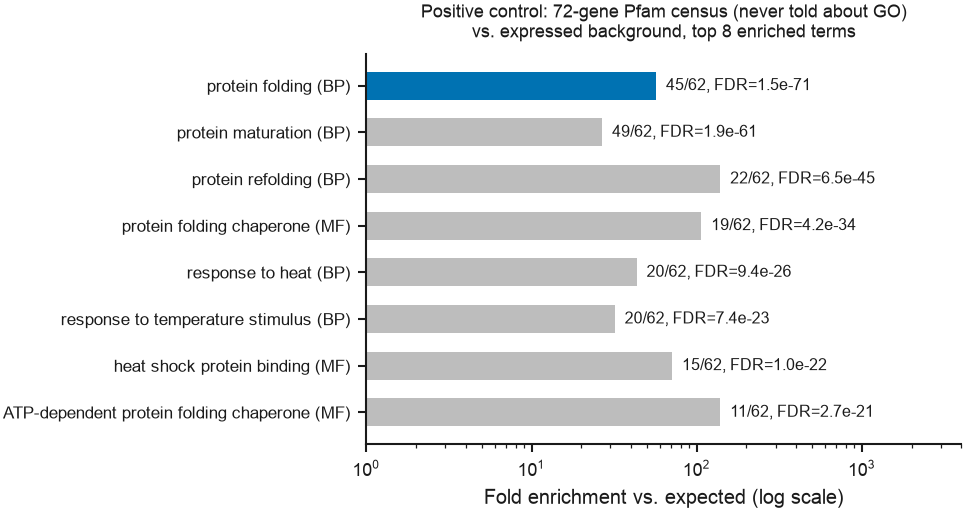

In [4]:
# Draw: the top 8 enriched terms, fold-enrichment on a log axis, FDR annotated.
# "protein folding" itself (the term the census was never told about) sits at the
# top - that is the check this figure exists to make visible.
fig, ax = plt.subplots(figsize=(THREEQ_W, THREEQ_W * 0.66))
y = np.arange(len(top8))[::-1]
colors = [BLUE if t == "protein folding" else GREY for t in top8["term"]]
ax.barh(y, top8["fold"], color=colors, height=0.6)
ax.set_xscale("log")
ax.set_yticks(y)
# BP / MF are the conventional GO namespace abbreviations. Truncating the raw
# namespace string instead gave "(bi)" and "(mo)", which say nothing to a reader.
NS_ABBREV = {"biological_process": "BP", "molecular_function": "MF",
             "cellular_component": "CC"}
missing = set(top8["namespace"]) - set(NS_ABBREV)
if missing:
    raise RuntimeError(f"Unmapped GO namespace(s) in the top 8: {missing}")
ax.set_yticklabels([f"{t} ({NS_ABBREV[ns]})" for t, ns in zip(top8["term"], top8["namespace"])],
                   fontsize=8)
ax.set_xlabel("Fold enrichment vs. expected (log scale)")
for yi, row in zip(y, top8.itertuples()):
    ax.text(row.fold * 1.15, yi, f"{row.k}/{row.n}, FDR={row.fdr_enrich:.1e}",
            va="center", fontsize=7.5, color=INK)
ax.set_xlim(1, 4000)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.set_title("Positive control: 72-gene Pfam census (never told about GO)\nvs. expressed background, top 8 enriched terms",
             fontsize=8.5, pad=8)

save(fig, "figureS1_pipeline_validation")
plt.show()